In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error

match   = pd.read_csv("../data/gold_match_with_league_standings.csv")
tickets = pd.read_csv("../data/gold_match_tickets.csv")
context = pd.read_csv("../data/gold_match_context.csv")

match = match[match["is_home_match"] == True]

df = match.merge(tickets, on="match_id", how="left")
df = df.merge(context, on="match_id", how="left")

if "match_date_x" in df.columns:
    df = df.rename(columns={"match_date_x": "match_date"})
elif "match_date_y" in df.columns:
    df = df.rename(columns={"match_date_y": "match_date"})

df = df[df["away_team"] != "OH Leuven"]
df = df.dropna(subset=["tickets_scanned", "last_result_vs_opponent"])

def parse_result(value):
    if value.startswith("W"): return 3
    elif value.startswith("D"): return 1
    elif value.startswith("L"): return 0
    return None

df["last_result_numeric"] = df["last_result_vs_opponent"].apply(parse_result)
df = df.dropna(subset=["last_result_numeric"])

df["match_date"] = pd.to_datetime(df["match_date"])
df = df.sort_values("match_date").reset_index(drop=True)

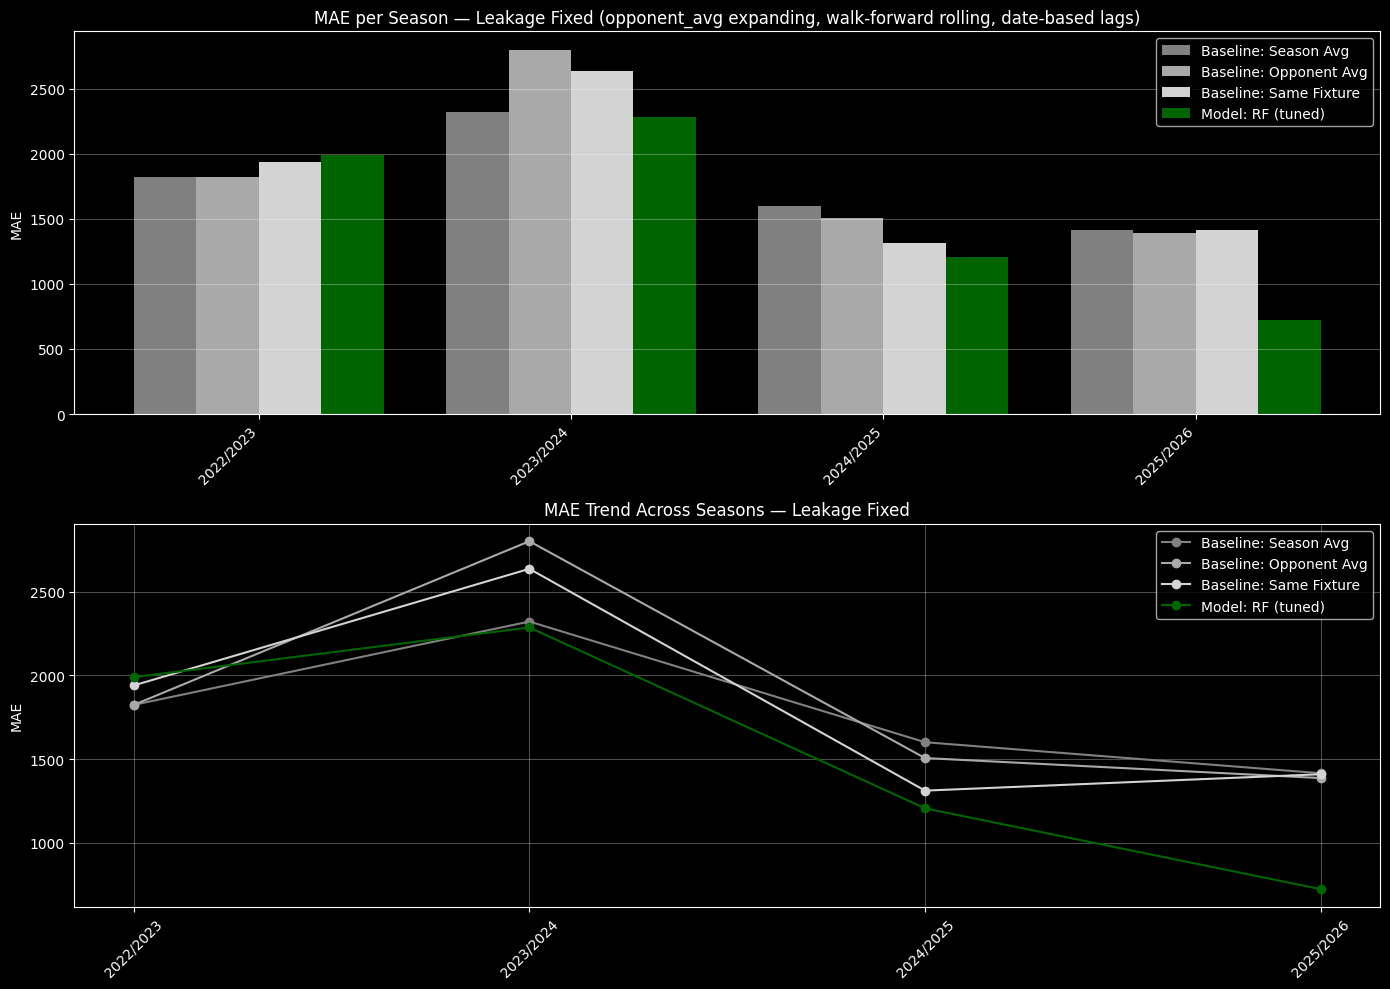

In [21]:
# ── FIX 1: Lag features filtered strictly by match_date, not by index ─────────
# Previously: df.index < current_idx relied on integer index order, which
# breaks if the DataFrame is ever re-sorted or re-indexed. Using match_date
# is robust and correctly excludes any test-season matches at the boundary.
records = []
for idx, row in df.iterrows():
    past = df[
        (df["away_team"] == row["away_team"]) &
        (df["match_date"] < row["match_date"])
    ]["last_result_numeric"]
    results = past.tail(3).tolist()
    records.append({
        "match_id":       row["match_id"],
        "result_minus_1": results[-1] if len(results) >= 1 else None,
        "result_minus_2": results[-2] if len(results) >= 2 else None,
        "result_minus_3": results[-3] if len(results) >= 3 else None,
    })

df_lag = pd.DataFrame(records)
df = df.merge(df_lag, on="match_id", how="left")
df["points_last_3"] = (
    df["result_minus_1"].fillna(0) +
    df["result_minus_2"].fillna(0) +
    df["result_minus_3"].fillna(0)
)

# ── FIX 2: opponent_avg computed as expanding mean over past matches only ──────
# Previously: opponent_avg_train = train.groupby(...).mean() computed a global
# average over ALL training rows including future ones. For match t, this
# leaked attendance figures from matches t+1, t+2, ... in the training set.
# Fix: shift(1).expanding().mean() within each opponent group — each row only
# sees the mean of matches strictly before it.
df = df.sort_values("match_date").reset_index(drop=True)
df["opponent_avg_expanding"] = (
    df.groupby("away_team")["tickets_scanned"]
    .transform(lambda x: x.shift(1).expanding().mean())
)

df["school_holiday_name"] = df["school_holiday_name"].fillna("None")

seasons = sorted(df["season"].unique())
print(f"Seasons available: {seasons}")

categorical_features = ["stage", "school_holiday_name"]
numerical_features   = [
    "opponent_avg_expanding",   # replaces opponent_avg (leak-free)
    "last_home_attendance",
    "rolling_avg_3",
    "matchday",
    "is_weekend",
    "academic_week",
]

features = numerical_features + categorical_features

season_results = []

for test_season in seasons:
    train = df[df["season"] != test_season].copy().sort_values("match_date")
    test  = df[df["season"] == test_season].copy().sort_values("match_date")

    if len(train) < 10 or len(test) < 5:
        continue

    # ── Lag-1 and rolling attendance features ────────────────────────────────
    # Training: use shift(1) so row t only sees t-1.
    train = train.copy()
    train["last_home_attendance"] = train["tickets_scanned"].shift(1)
    train["rolling_avg_3"]        = train["tickets_scanned"].shift(1).rolling(3).mean()
    train = train.dropna(subset=["last_home_attendance", "rolling_avg_3"])

    # ── FIX 3: Walk-forward update of rolling features on the test set ────────
    # Previously: both features were frozen at the last training value for every
    # test match — a static scalar applied to all 13+ test rows. This isn't
    # leakage, but it degrades accuracy as the season progresses. We now carry a
    # running buffer of the last 3 actual (or predicted) attendance values and
    # update it match-by-match. For real-time use, replace attendance_buffer
    # entries with actual scanned counts as they become available.
    attendance_buffer = list(train["tickets_scanned"].tail(3).values)

    last_home_attendances = []
    rolling_avg_3s        = []

    for _ in range(len(test)):
        last_home_attendances.append(attendance_buffer[-1])
        rolling_avg_3s.append(sum(attendance_buffer[-3:]) / min(3, len(attendance_buffer)))
        # Placeholder: append the rolling mean as a stand-in for the true value.
        # In production, replace this with the actual scanned count after each match.
        attendance_buffer.append(rolling_avg_3s[-1])

    test = test.copy()
    test["last_home_attendance"] = last_home_attendances
    test["rolling_avg_3"]        = rolling_avg_3s

    # opponent_avg for test: use the expanding value already computed on df
    # (which only saw matches before each date). Fill NaN opponents (new clubs)
    # with the training set global mean.
    global_train_mean = train["tickets_scanned"].mean()
    train["opponent_avg_expanding"] = train["opponent_avg_expanding"].fillna(global_train_mean)
    test["opponent_avg_expanding"]  = test["opponent_avg_expanding"].fillna(global_train_mean)

    train = train.dropna(subset=features)
    test  = test.dropna(subset=features)

    if len(test) == 0:
        continue

    X_train = pd.get_dummies(train[features], columns=categorical_features, drop_first=True)
    X_test  = pd.get_dummies(test[features],  columns=categorical_features, drop_first=True)
    X_test  = X_test.reindex(columns=X_train.columns, fill_value=0)

    y_train = train["tickets_scanned"]
    y_test  = test["tickets_scanned"]

    # Baselines
    season_avg_val   = train["tickets_scanned"].mean()
    opponent_avg_val = test["opponent_avg_expanding"]           # leak-free expanding avg
    same_fixture     = train.groupby("away_team")["tickets_scanned"].last()

    mae_season   = mean_absolute_error(y_test, [season_avg_val] * len(y_test))
    mae_opponent = mean_absolute_error(y_test, opponent_avg_val)
    mae_fixture  = mean_absolute_error(y_test, test["away_team"].map(same_fixture).fillna(season_avg_val))

    rf = RandomForestRegressor(
        n_estimators=200, max_depth=5,
        min_samples_split=5, min_samples_leaf=2,
        random_state=42,
    )
    rf.fit(X_train, y_train)
    y_pred = rf.predict(X_test)
    mae_rf = mean_absolute_error(y_test, y_pred)

    season_results.append({
        "season":                 test_season,
        "n_matches":              len(y_test),
        "Baseline: Season Avg":   mae_season,
        "Baseline: Opponent Avg": mae_opponent,
        "Baseline: Same Fixture": mae_fixture,
        "Model: RF (tuned)":      mae_rf,
    })
    print(
        f"{test_season} — RF: {mae_rf:.0f} | Opponent Avg: {mae_opponent:.0f} | "
        f"Season Avg: {mae_season:.0f} | Same Fixture: {mae_fixture:.0f} | n={len(y_test)}"
    )

In [ ]:
results_df = pd.DataFrame(season_results).set_index("season")

cols   = ["Baseline: Season Avg", "Baseline: Opponent Avg", "Baseline: Same Fixture", "Model: RF (tuned)"]
colors = ["grey", "darkgrey", "lightgrey", "darkgreen"]

x     = range(len(results_df))
width = 0.2

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

for i, (col, color) in enumerate(zip(cols, colors)):
    axes[0].bar([xi + i * width for xi in x], results_df[col], width=width, label=col, color=color)

axes[0].set_xticks([xi + width * 1.5 for xi in x])
axes[0].set_xticklabels(results_df.index, rotation=45, ha="right")
axes[0].set_ylabel("MAE")
axes[0].set_title("MAE per Season — Leakage Fixed (opponent_avg expanding, walk-forward rolling, date-based lags)")
axes[0].legend()
axes[0].grid(axis="y", alpha=0.3)

for col, color in zip(cols, colors):
    axes[1].plot(results_df.index, results_df[col], marker="o", label=col, color=color)

axes[1].set_ylabel("MAE")
axes[1].set_title("MAE Trend Across Seasons — Leakage Fixed")
axes[1].legend()
axes[1].grid(alpha=0.3)
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

In [22]:
X_train
X_test

,opponent_avg_expanding,last_home_attendance,rolling_avg_3,matchday,is_weekend,academic_week,stage_Regular Season,school_holiday_name_Carnival Holiday,school_holiday_name_Christmas Holiday,school_holiday_name_Easter Holiday,school_holiday_name_None,school_holiday_name_Summer Holiday
55,5904.500000,5025.000000,5268.000000,1.0,True,48,0,0,0,0,False,True
56,6889.000000,5268.000000,5302.666667,4.0,False,50,0,0,0,0,False,True
57,7665.000000,5302.666667,5198.555556,6.0,True,53,0,0,0,0,False,True
58,10778.666667,5198.555556,5256.407407,9.0,False,4,0,0,0,0,True,False
59,9490.333333,5256.407407,5252.543210,11.0,True,7,0,0,0,0,True,False
60,6812.500000,5252.543210,5235.835391,13.0,True,9,0,0,0,0,False,False
61,6555.500000,5235.835391,5248.262003,15.0,True,12,0,0,0,0,True,False
62,7785.000000,5248.262003,5245.546868,17.0,True,14,0,0,0,0,True,False
63,6095.666667,5245.546868,5243.214754,19.0,True,16,0,0,0,0,True,False
64,7474.333333,5243.214754,5245.674541,22.0,True,21,0,0,0,0,True,False


In [44]:
# len(y_pred)
# len(X_test)
X_test.columns

Index(['opponent_avg_expanding', 'last_home_attendance', 'rolling_avg_3',
       'matchday', 'is_weekend', 'academic_week', 'stage_Regular Season',
       'school_holiday_name_Carnival Holiday',
       'school_holiday_name_Christmas Holiday',
       'school_holiday_name_Easter Holiday', 'school_holiday_name_None',
       'school_holiday_name_Summer Holiday'],
      dtype='str')

In [37]:
comparing = pd.concat([y_test.reset_index(drop=True), pd.DataFrame(y_pred, columns=["pred"])], axis=1)

In [39]:
comparing["diff"] = comparing["pred"] - comparing["tickets_scanned"]

In [41]:
comparing["diff_abs"] = comparing["diff"].abs()

In [43]:
comparing["diff_abs"].sum() / len(comparing["diff_abs"])

np.float64(724.6483742400761)